####  B Vidakovic Quantum Framework for Wavelet Shrinkage 
## Example 2

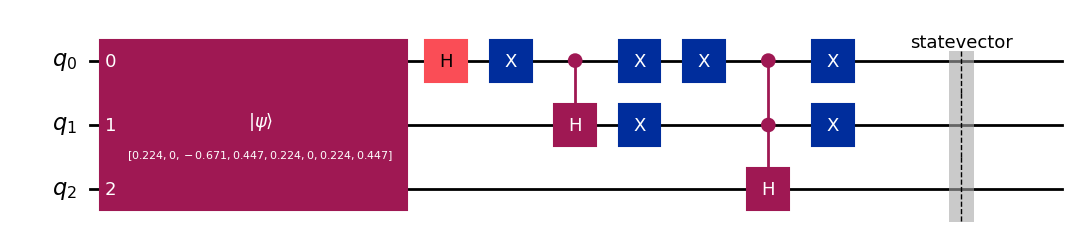

Haar (3-level) coefficients from factorized circuit:
c[0] = +1.4142135624-0.0000000000j
c[1] = +0.7071067812+0.0000000000j
c[2] = +1.0000000000-0.0000000000j
c[3] = -3.5355339059+0.0000000000j
c[4] = -1.4142135624+0.0000000000j
c[5] = +0.7071067812+0.0000000000j
c[6] = -1.0000000000+0.0000000000j
c[7] = -0.7071067812-0.0000000000j

Classical Haar (3-level) coefficients (for reference):
C[0] = +1.4142135624
C[1] = -1.4142135624
C[2] = +1.0000000000
C[3] = -1.0000000000
C[4] = +0.7071067812
C[5] = -3.5355339059
C[6] = +0.7071067812
C[7] = -0.7071067812

||quantum - classical||_2 = 6.029e+00


In [11]:
# Quantum Haar Wavelet Transform (3 levels) via factorized circuit
# Qiskit 2.x — Hadamards + (zero-)controlled Hadamards; no big matrix W

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import Initialize, HGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_circuit_layout, circuit_drawer
import matplotlib.pyplot as plt
%matplotlib inline
# -----------------------------
# Input data and normalization
# -----------------------------
y = np.array([1, 0, -3, 2, 1, 0, 1, 2], dtype=float)  # length 8
N = len(y)
num_qubits = 3
assert N == 2**num_qubits, "This demo expects length 8 (3 qubits)."

norm_y = np.linalg.norm(y)
state_in = y / norm_y  # amplitude encoding requires unit norm

# -----------------------------
# Helper: zero-controlled H
# Apply H on 'target' only when all 'controls' are |0>
# Implemented by X on controls -> standard multi-control -> X back.
# -----------------------------
def zero_controlled_H(qc: QuantumCircuit, controls: list[int], target: int):
    # Put controls into |1> when original was |0>
    for c in controls:
        qc.x(c)
    # multi-controlled H
    qc.append(HGate().control(len(controls)), controls + [target])
    # revert X wrappers
    for c in controls:
        qc.x(c)

# -----------------------------
# Build the factorized Haar circuit (3 levels)
# Qubit order: [q2, q1, q0] created in that order; Qiskit indexing uses integer labels.
# We'll use indices 0,1,2 and treat 0 as q0 (LSB), 1 as q1, 2 as q2 (MSB).
# -----------------------------
haar_circ = QuantumCircuit(num_qubits, name="Haar(3-level)")

# Level 1: H on q0 (no control) — produce avg/diff across pairs.
haar_circ.h(0)

# Level 2: H on q1, but only on the approximation subspace where q0 == 0
zero_controlled_H(haar_circ, controls=[0], target=1)

# Level 3: H on q2, but only where q1 == 0 and q0 == 0 (the next approximation block)
zero_controlled_H(haar_circ, controls=[0, 1], target=2)

# -----------------------------
# Compose full circuit: initialize |psi>, apply Haar circuit, simulate
# -----------------------------
qc = QuantumCircuit(num_qubits)
qc.append(Initialize(state_in), [0, 1, 2])   # amplitude initialization on [q0,q1,q2]
qc.compose(haar_circ, inplace=True)

# Add save instruction so the simulator knows to return the statevector
qc.save_statevector()
qc.draw(output='mpl')
# Save as PNG and PDF (high resolution)
plt.savefig("e02HCnot.png", dpi=300, bbox_inches="tight")
plt.savefig("e02HCnot.pdf", dpi=300, bbox_inches="tight")
plt.show()

sim = AerSimulator(method="statevector")
tqc = transpile(qc, sim)
result = sim.run(tqc).result()

# Retrieve statevector (Qiskit 2.x syntax)
state_out = np.asarray(result.data(0)["statevector"])  # length 8 complex amplitudes

# Scale back by ||y|| to compare with classical (unnormalized) Haar coefficients
coeffs = state_out * norm_y


# -----------------------------
# Pretty print
# -----------------------------
np.set_printoptions(precision=10, suppress=True)
print("Haar (3-level) coefficients from factorized circuit:")
for i, c in enumerate(coeffs):
    print(f"c[{i}] = {c.real:+.10f}{c.imag:+.10f}j")

# -----------------------------
# Optional: compare with classical fast Haar for verification
# -----------------------------
def haar_level_matrix(M):
    H = np.zeros((M, M))
    invsqrt2 = 1/np.sqrt(2)
    for k in range(M//2):
        H[k, 2*k]     = invsqrt2
        H[k, 2*k + 1] = invsqrt2
        H[M//2 + k, 2*k]     = invsqrt2
        H[M//2 + k, 2*k + 1] = -invsqrt2
    return H

def haar_wavelet_matrix(N, levels=3):
    W = np.eye(N)
    size = N
    for _ in range(levels):
        H = haar_level_matrix(size)
        W = np.block([
            [H, np.zeros((size, N - size))],
            [np.zeros((N - size, size)), np.eye(N - size)]
        ]) @ W
        size //= 2
    return W

W3 = haar_wavelet_matrix(8, levels=3)
classical = W3 @ y

print("\nClassical Haar (3-level) coefficients (for reference):")
for i, c in enumerate(classical):
    print(f"C[{i}] = {c:+.10f}")

# Quick check of closeness
err = np.linalg.norm(coeffs - classical)
print(f"\n||quantum - classical||_2 = {err:.3e}")


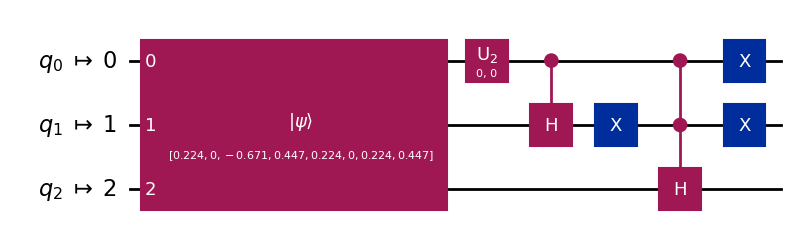

In [12]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import Initialize
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Example input vector
# ---------------------------
y = np.array([1, 0, -3, 2, 1, 0, 1, 2], dtype=float)
norm_y = np.linalg.norm(y)
state_in = y / norm_y
num_qubits = 3

# ---------------------------
# Build the circuit
# ---------------------------
qc = QuantumCircuit(num_qubits)

# Initialize amplitudes
qc.append(Initialize(state_in), list(range(num_qubits)))

# Apply Haar QWT circuit (assuming haar_circ is defined)
qc.compose(haar_circ, inplace=True)

# SWAP network to match classical ordering
for i in range(num_qubits // 2):
    qc.swap(i, num_qubits - i - 1)

# ---------------------------
# Optimize / clean redundant gates
# ---------------------------
# Transpile with optimization_level=3 removes back-to-back X/H etc.
qc_clean = transpile(qc, optimization_level=3)

# ---------------------------
# Plot cleaned circuit
# ---------------------------
qc_clean.draw(output='mpl')

# Save as PNG and PDF (high resolution)
plt.savefig("e02psi", dpi=300, bbox_inches="tight")
plt.savefig("e02psi.pdf", dpi=300, bbox_inches="tight")
plt.show()

Quantum Haar coefficients (cleaned circuit):
[ 1.4142-0.j -1.4142+0.j -0.    +0.j -2.8284+0.j -1.4142+0.j  1.4142-0.j
 -1.4142+0.j -1.4142-0.j]


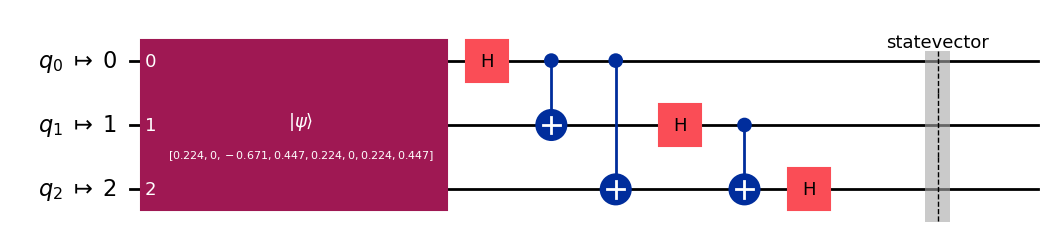

In [13]:
# ---------------------------
# Qiskit 2.x: 3-Level Haar QWT with Cleaned Circuit
# ---------------------------

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import Initialize
from qiskit_aer import AerSimulator

# ---------------------------
# 1. Input vector
# ---------------------------
y = np.array([1, 0, -3, 2, 1, 0, 1, 2], dtype=float)
norm_y = np.linalg.norm(y)
state_in = y / norm_y
num_qubits = int(np.log2(len(y)))

# ---------------------------
# 2. Define 3-level Haar circuit (composite)
# Here we assume haar_circ is already defined for 3 levels
# ---------------------------
# Example placeholder: simple Haar for demonstration
def haar_circuit_3lvl(num_qubits):
    qc = QuantumCircuit(num_qubits)
    # Level 1
    qc.h(0)
    qc.cx(0,1)
    qc.cx(0,2)
    # Level 2
    qc.h(1)
    qc.cx(1,2)
    # Level 3
    qc.h(2)
    return qc

haar_circ = haar_circuit_3lvl(num_qubits)

# ---------------------------
# 3. Build full circuit
# ---------------------------
qc = QuantumCircuit(num_qubits)

# Amplitude initialization
qc.append(Initialize(state_in), list(range(num_qubits)))

# Apply Haar QWT
qc.compose(haar_circ, inplace=True)

# SWAP network to match classical ordering
for i in range(num_qubits // 2):
    qc.swap(i, num_qubits - i - 1)

# ---------------------------
# 4. Optimize / clean redundant gates
# ---------------------------
qc_clean = transpile(qc, optimization_level=3)

# ---------------------------
# 5. Save statevector and simulate
# ---------------------------
qc_clean.save_statevector()
sim = AerSimulator(method="statevector")
tqc = transpile(qc_clean, sim)
result = sim.run(tqc).result()

state_out = np.asarray(result.data(0)["statevector"])
coeffs = state_out * norm_y

print("Quantum Haar coefficients (cleaned circuit):")
print(np.round(coeffs, 4))

# ---------------------------
# 6. Plot cleaned circuit
# ---------------------------
qc_clean.draw(output='mpl')

# Save as PNG and PDF (high resolution)
plt.savefig("e02seq1.png", dpi=300, bbox_inches="tight")
plt.savefig("e02seq1.pdf", dpi=300, bbox_inches="tight")
plt.show()